In [ ]:
#L’algorithme Apriori
!pip install pandas mlxtend

In [4]:
import pandas as pd

 

# Charger le dataset (chemin à adapter selon l'emplacement du fichier)

df = pd.read_csv('Market_Basket_Optimisation.csv', header=None)

df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil
1,burgers,meatballs,eggs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,chutney,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,turkey,avocado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,mineral water,milk,energy bar,whole wheat rice,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#Préparation des données
transactions = []

for i in range(df.shape[0]):

    panier = [str(df.values[i,j]) for j in range(df.shape[1]) if str(df.values[i,j]) != 'nan']

    transactions.append(panier)

In [ ]:
# Encodage des transactions
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()

te_ary = te.fit(transactions).transform(transactions)

df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

df_encoded.head()

,asparagus,almonds,antioxydant juice,asparagus,avocado,babies food,bacon,barbecue sauce,black tea,blueberries,...,turkey,vegetables mix,water spray,white wine,whole weat flour,whole wheat pasta,whole wheat rice,yams,yogurt cake,zucchini
0,False,True,True,False,True,False,False,False,False,False,...,False,True,False,False,True,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,True,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False


In [ ]:
#Extraction des itemsets fréquents avec Apriori
from mlxtend.frequent_patterns import apriori

 

# On fixe un support minimum (ex: 0.03 = 3% des transactions)

frequent_itemsets = apriori(df_encoded, min_support=0.03, use_colnames=True)

frequent_itemsets.sort_values(by='support', ascending=False).head(10)

,support,itemsets
25,0.238368,(mineral water)
11,0.179709,(eggs)
31,0.174110,(spaghetti)
13,0.170911,(french fries)
7,0.163845,(chocolate)
18,0.132116,(green tea)
24,0.129583,(milk)
19,0.098254,(ground beef)
16,0.095321,(frozen vegetables)
27,0.095054,(pancakes)


In [ ]:
#Génération des règles d’association
from mlxtend.frequent_patterns import association_rules

 

# On fixe un seuil de confiance (ex: 0.2 = 20%)

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.2)

rules.sort_values(by='lift', ascending=False).head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
18,(spaghetti),(ground beef),0.174110,0.098254,0.039195,0.225115,2.291162,1.0,0.022088,1.163716,0.682343,0.168096,0.140684,0.312015
19,(ground beef),(spaghetti),0.098254,0.174110,0.039195,0.398915,2.291162,1.0,0.022088,1.373997,0.624943,0.168096,0.272197,0.312015
17,(ground beef),(mineral water),0.098254,0.238368,0.040928,0.416554,1.747522,1.0,0.017507,1.305401,0.474369,0.138413,0.233952,0.294127
15,(frozen vegetables),(mineral water),0.095321,0.238368,0.035729,0.374825,1.572463,1.0,0.013007,1.218270,0.402413,0.119911,0.179164,0.262357
23,(spaghetti),(milk),0.174110,0.129583,0.035462,0.203675,1.571779,1.0,0.012900,1.093043,0.440468,0.132207,0.085123,0.238669
22,(milk),(spaghetti),0.129583,0.174110,0.035462,0.273663,1.571779,1.0,0.012900,1.137061,0.417935,0.132207,0.120540,0.238669
21,(mineral water),(milk),0.238368,0.129583,0.047994,0.201342,1.553774,1.0,0.017105,1.089850,0.467950,0.150000,0.082443,0.285856
20,(milk),(mineral water),0.129583,0.238368,0.047994,0.370370,1.553774,1.0,0.017105,1.209650,0.409465,0.150000,0.173315,0.285856
3,(milk),(chocolate),0.129583,0.163845,0.032129,0.247942,1.513276,1.0,0.010898,1.111823,0.389677,0.122959,0.100577,0.222018
24,(pancakes),(mineral water),0.095054,0.238368,0.033729,0.354839,1.488616,1.0,0.011071,1.180529,0.362712,0.112544,0.152922,0.248169


In [9]:
# Afficher les règles les plus intéressantes

for idx, row in rules.sort_values(by='lift', ascending=False).head(10).iterrows():

    print(f"Règle : {set(row['antecedents'])} => {set(row['consequents'])}")

    print(f" - Support : {row['support']:.2f}")

    print(f" - Confiance : {row['confidence']:.2f}")

    print(f" - Lift : {row['lift']:.2f}\n")

Règle : {'spaghetti'} => {'ground beef'}
 - Support : 0.04
 - Confiance : 0.23
 - Lift : 2.29

Règle : {'ground beef'} => {'spaghetti'}
 - Support : 0.04
 - Confiance : 0.40
 - Lift : 2.29

Règle : {'ground beef'} => {'mineral water'}
 - Support : 0.04
 - Confiance : 0.42
 - Lift : 1.75

Règle : {'frozen vegetables'} => {'mineral water'}
 - Support : 0.04
 - Confiance : 0.37
 - Lift : 1.57

Règle : {'spaghetti'} => {'milk'}
 - Support : 0.04
 - Confiance : 0.20
 - Lift : 1.57

Règle : {'milk'} => {'spaghetti'}
 - Support : 0.04
 - Confiance : 0.27
 - Lift : 1.57

Règle : {'mineral water'} => {'milk'}
 - Support : 0.05
 - Confiance : 0.20
 - Lift : 1.55

Règle : {'milk'} => {'mineral water'}
 - Support : 0.05
 - Confiance : 0.37
 - Lift : 1.55

Règle : {'milk'} => {'chocolate'}
 - Support : 0.03
 - Confiance : 0.25
 - Lift : 1.51

Règle : {'pancakes'} => {'mineral water'}
 - Support : 0.03
 - Confiance : 0.35
 - Lift : 1.49



C:\Users\YESSMINE\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
C:\Users\YESSMINE\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
C:\Users\YESSMINE\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


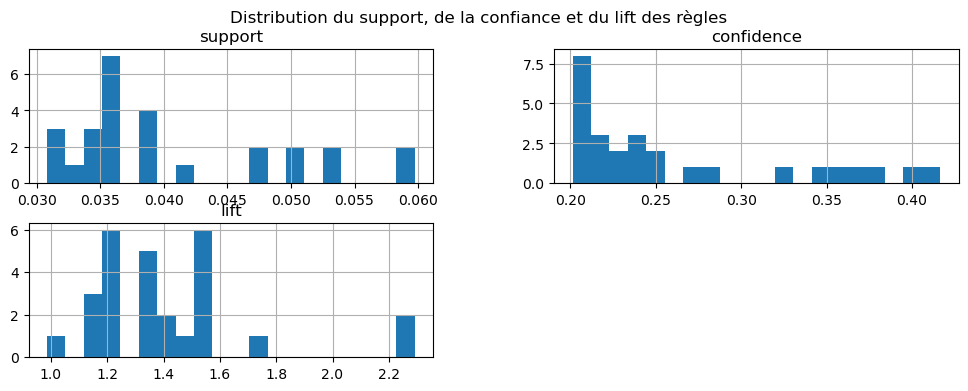

In [ ]:
#. Visualisation rapide (optionnelle)
import matplotlib.pyplot as plt

 

rules[['support', 'confidence', 'lift']].hist(bins=20, figsize=(12,4))

plt.suptitle('Distribution du support, de la confiance et du lift des règles')

plt.show()